In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from app.model_loader import load_model, CLASSES
from app.inference import predict
from app.utils import similarity

In [3]:
model = load_model()

DATA_DIR = "/home/divye/Desktop/cnn/data/2750"

THRESHOLD = 0.638

In [4]:
def load_random_image(class_name):

    folder = os.path.join(DATA_DIR, class_name)

    image_name = random.choice(os.listdir(folder))

    path = os.path.join(folder, image_name)

    return Image.open(path).convert("RGB"), path


def create_heatmap(img1, img2):

    a = np.array(img1.resize((224,224)))
    b = np.array(img2.resize((224,224)))

    diff = cv2.absdiff(a,b)

    gray = cv2.cvtColor(
        diff,
        cv2.COLOR_RGB2GRAY
    )

    heat = cv2.applyColorMap(
        gray,
        cv2.COLORMAP_JET
    )

    return heat

In [5]:
def evaluate_pair(before_class, after_class):

    img1, path1 = load_random_image(before_class)
    img2, path2 = load_random_image(after_class)

    pred1, conf1, emb1 = predict(model, img1)
    pred2, conf2, emb2 = predict(model, img2)

    sim = similarity(emb1, emb2)

    changed = sim < THRESHOLD

    heat = create_heatmap(img1, img2)

    fig, ax = plt.subplots(1,3, figsize=(15,5))

    ax[0].imshow(img1)
    ax[0].set_title(
        f"Before\nGT:{before_class}\nPred:{CLASSES[pred1]}"
    )

    ax[1].imshow(img2)
    ax[1].set_title(
        f"After\nGT:{after_class}\nPred:{CLASSES[pred2]}"
    )

    ax[2].imshow(cv2.cvtColor(heat, cv2.COLOR_BGR2RGB))
    ax[2].set_title("Change Heatmap")

    for a in ax:
        a.axis("off")

    plt.suptitle(
        f"Similarity = {sim:.3f} | Change = {changed}"
    )

    plt.tight_layout()

    plt.show()

    print("="*60)
    print("Before Image :", os.path.basename(path1))
    print("After Image  :", os.path.basename(path2))
    print("Prediction 1 :", CLASSES[pred1], f"({conf1:.3f})")
    print("Prediction 2 :", CLASSES[pred2], f"({conf2:.3f})")
    print("Similarity   :", round(sim,3))
    print("Decision     :", "CHANGE" if changed else "NO CHANGE")
    print("="*60)

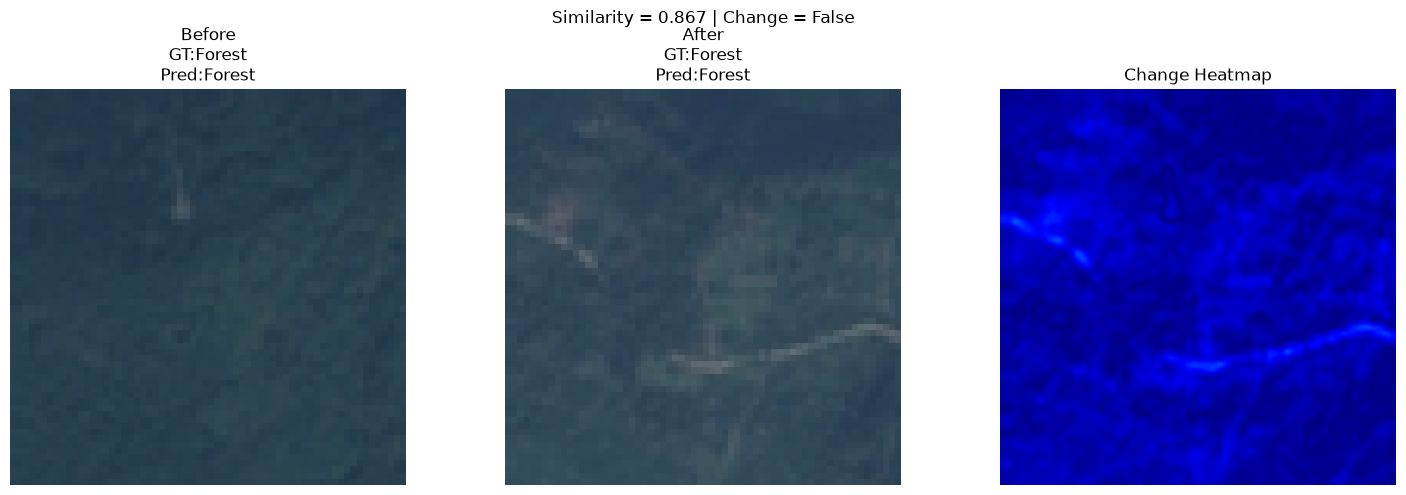

Before Image : Forest_2632.jpg
After Image  : Forest_2287.jpg
Prediction 1 : Forest (1.000)
Prediction 2 : Forest (0.939)
Similarity   : 0.867
Decision     : NO CHANGE


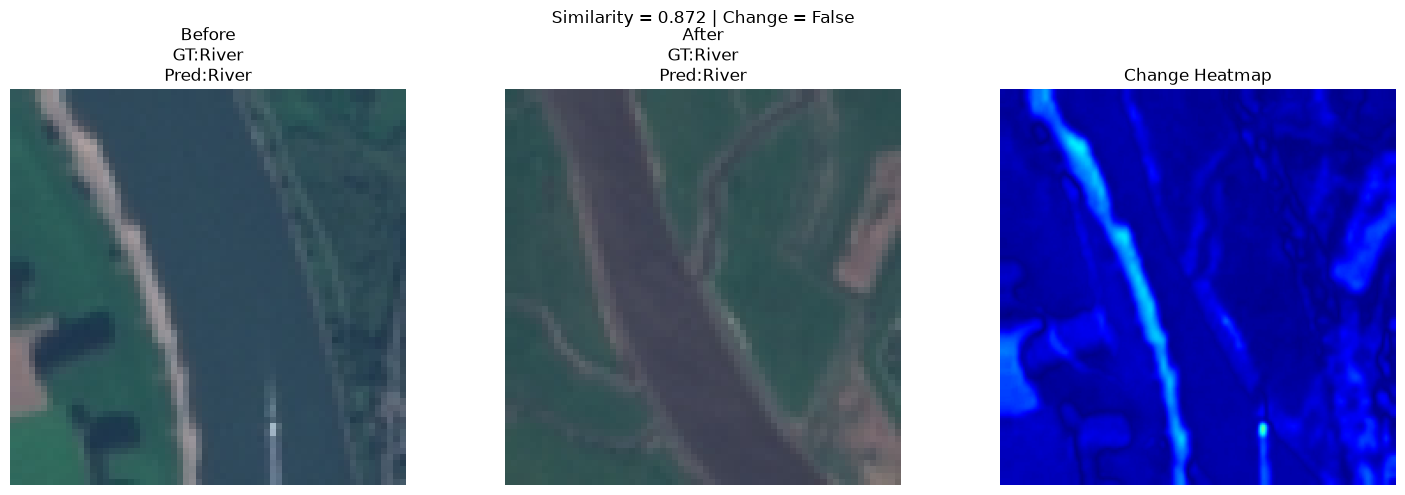

Before Image : River_740.jpg
After Image  : River_1021.jpg
Prediction 1 : River (1.000)
Prediction 2 : River (1.000)
Similarity   : 0.872
Decision     : NO CHANGE


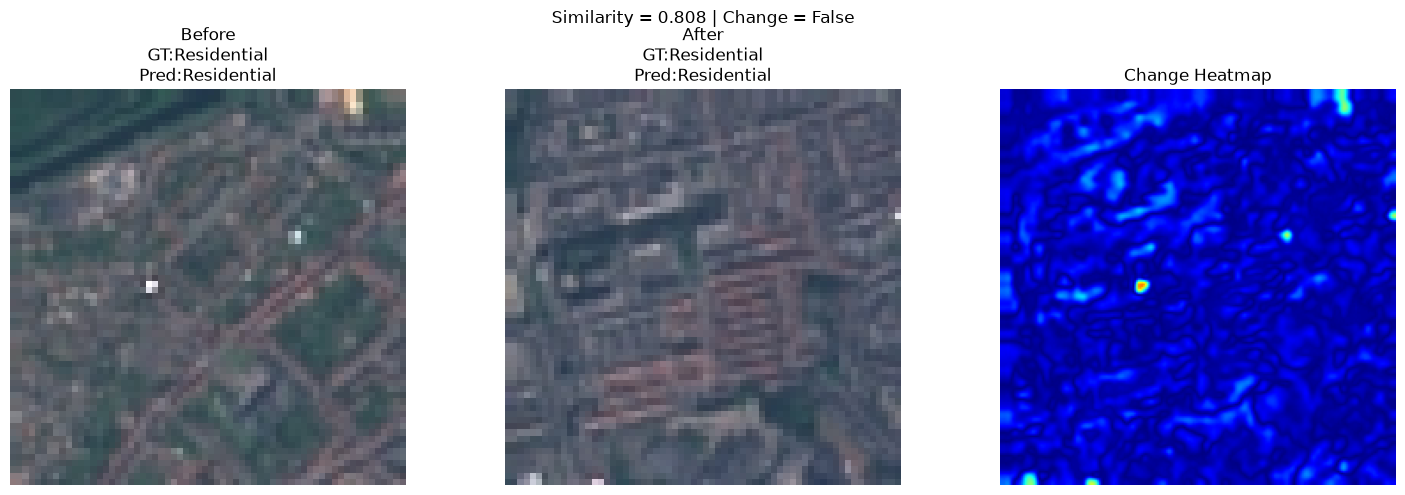

Before Image : Residential_701.jpg
After Image  : Residential_1597.jpg
Prediction 1 : Residential (1.000)
Prediction 2 : Residential (1.000)
Similarity   : 0.808
Decision     : NO CHANGE


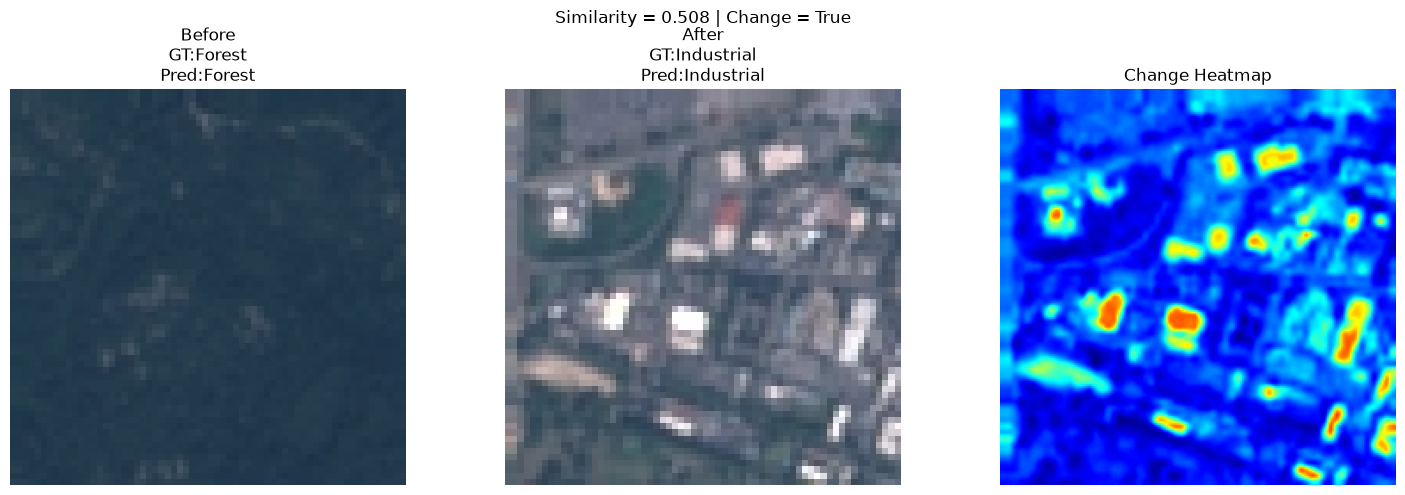

Before Image : Forest_2928.jpg
After Image  : Industrial_2181.jpg
Prediction 1 : Forest (0.999)
Prediction 2 : Industrial (1.000)
Similarity   : 0.508
Decision     : CHANGE


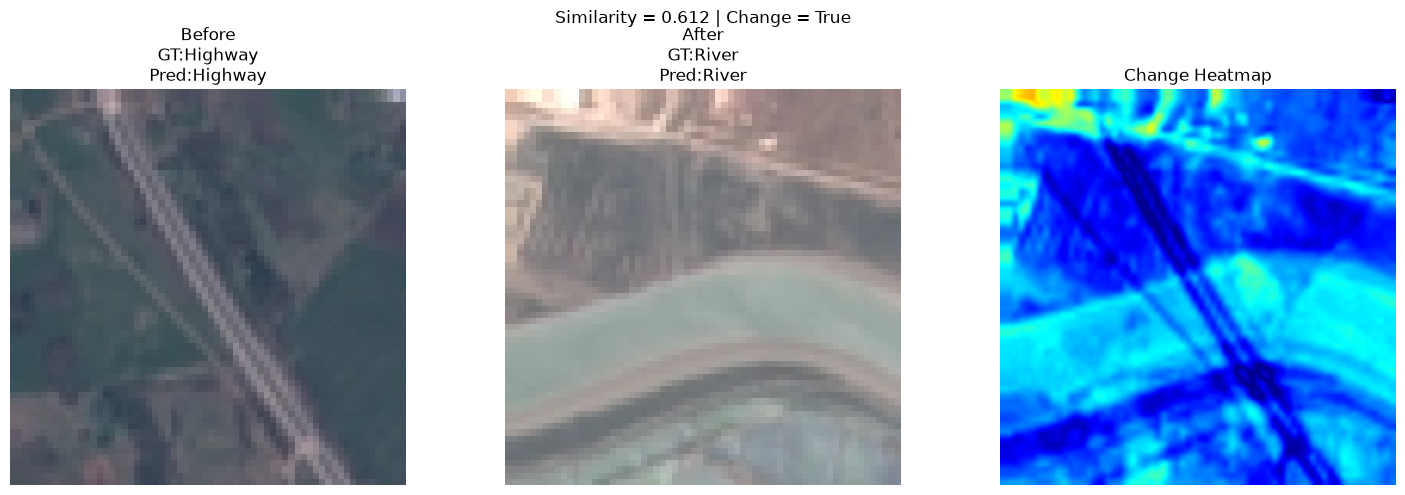

Before Image : Highway_605.jpg
After Image  : River_699.jpg
Prediction 1 : Highway (0.999)
Prediction 2 : River (1.000)
Similarity   : 0.612
Decision     : CHANGE


In [6]:
pairs = [

    ("Forest","Forest"),

    ("River","River"),

    ("Residential","Residential"),

    ("Forest","Industrial"),

    ("Highway","River")

]

for before, after in pairs:

    evaluate_pair(before, after)